In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import sys
import astropy.cosmology as cosmology
from matplotlib.legend_handler import HandlerTuple
import warnings
from ks_error import ks_err
from calc_kcor import calc_kcor
warnings.filterwarnings("ignore")

<Figure size 640x480 with 0 Axes>

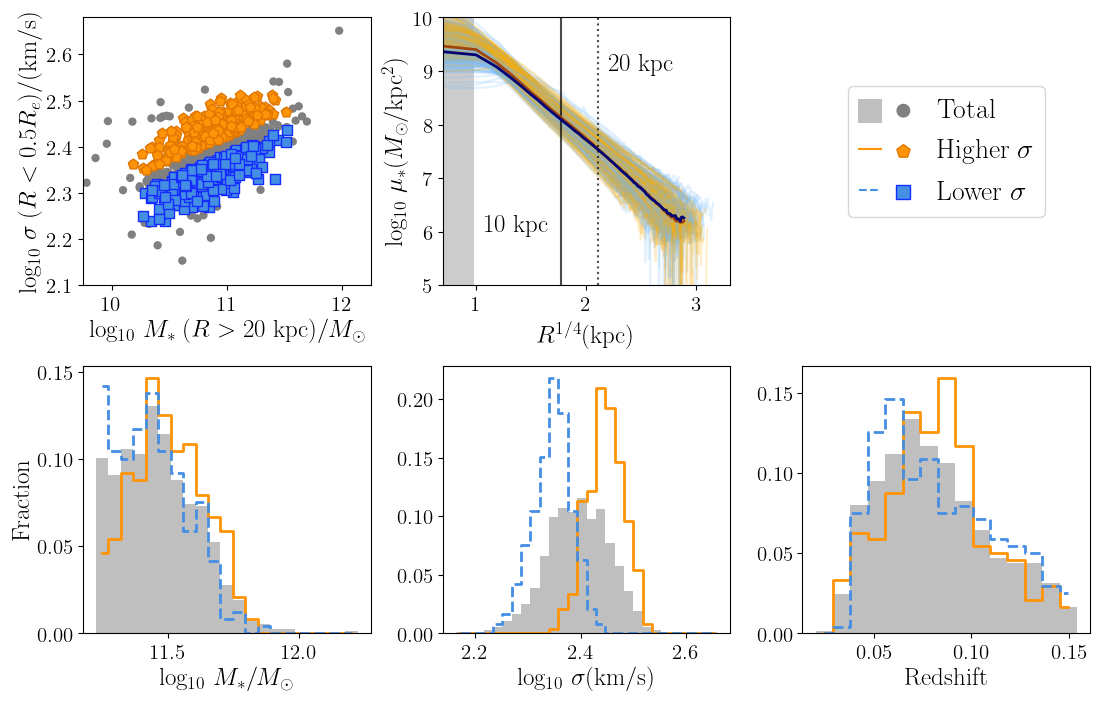

<Figure size 640x480 with 0 Axes>

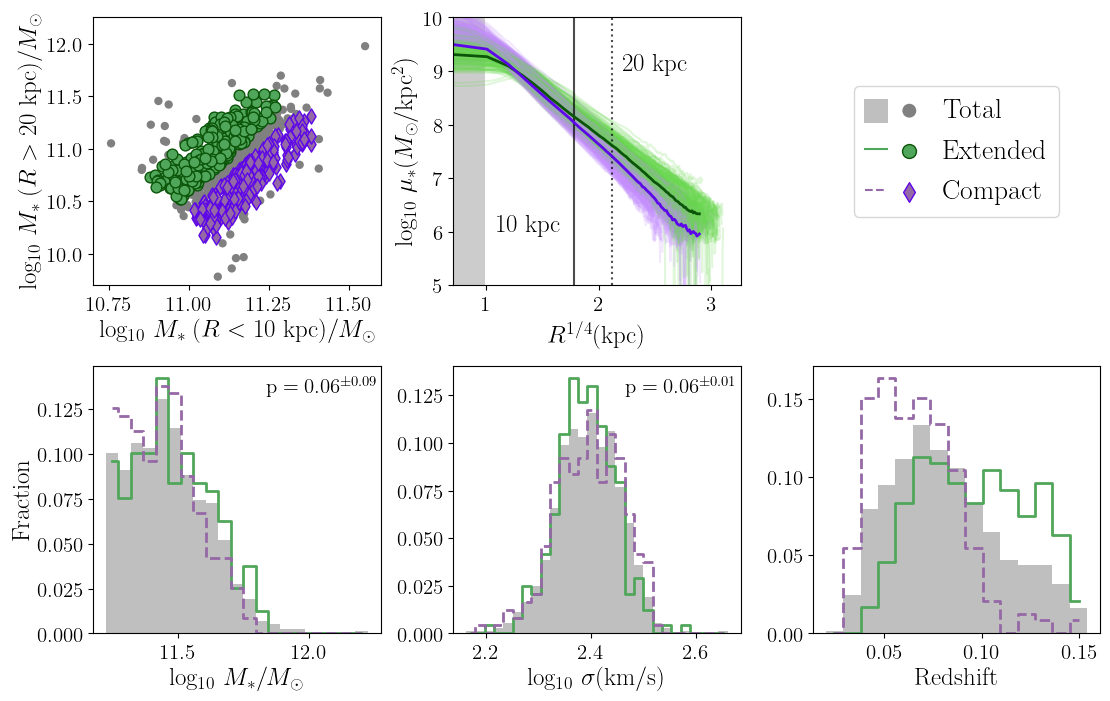

<Figure size 640x480 with 0 Axes>

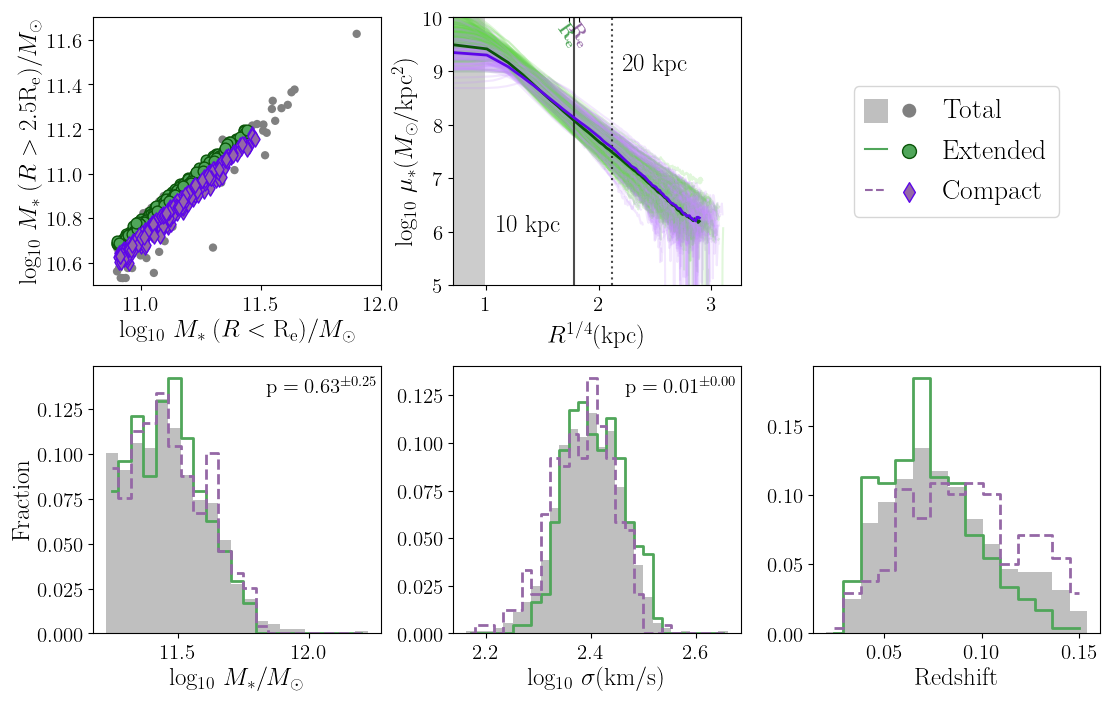

In [4]:
if __name__ == '__main__':
    solar_l = {'u': 6.39, 'g': 5.11, 'r': 4.65, 'i': 4.53,
               'z': 4.5}
    r_band = {'g': 3.214, 'r': 2.165, 'i': 1.592, 'z': 1.211}
    split_type = ['m20kpc_v_sigmacen', 'm10kpc_v_m20kpc','mre_v_m2re']
    titles = ['', '', r'$\mathbf{Compact\ vs.\ Extended}$', r'$\mathbf{Low\ \sigma\ vs.\ High\ \sigma}$']
    plt.rcParams.update({
            "text.usetex": True,
            "font.family": "Charter",
            "xtick.labelsize": 15,
            "ytick.labelsize": 15,
            "axes.labelsize": 16,
            "axes.labelweight": "bold"
        })
    drp = fits.open('../data/drpall-v3_1_1.fits')

    parameters = fits.open('../data/parameters_reff2_2.fits')
    manga_sga = fits.open('../data/manga_sga_z.fits')
    sga_mass = fits.open('../data/sga_mass_new_28mag2.fits')
    mask_hdu = fits.open('../data/sample_mask_new2.fits')
    split = fits.open('../data/sample_split_outliers_total2.fits')


    sga = fits.open('../data/SGA-2020.fits')

    stack = fits.open('../data/stacked_smooth_sigma300_mask_new2.fits')
    cosm = cosmology.FlatLambdaCDM(70, 0.3, 2.725, Ob0=0.046)
    factor_decalz = {'g': [0.08804478, -0.01202266],
                     'r': [0.097115220, -0.005264246],
                     'z': [0.0504410920, -0.0002501634]}
    factor_bass = {'g': [0.011121011, -0.009446287],
                   'r': [0.080892829, -0.003455136],
                   'z': [0.073761688, 0.004807630]}

    gals = parameters[1].data['plateifu']
    total_mass = parameters[1].data['mass_sga_rc15']
    sigma_cen = parameters[1].data['sigma_cen']
    m_in_10kpc = parameters[1].data['Min_10kpc']
    m_out_20kpc = parameters[1].data['Mout_20kpc']
    m_in_re = parameters[1].data['Min_re']
    m_out_2re = parameters[1].data['Mout_2re']
    select_data = {'mtot_v_m20kpc': [total_mass, m_out_20kpc,
                                     r'$\mathrm{log_{10}}\ M_*/M_\odot$',
                                     r'$\mathrm{log_{10}}\ M_*(R>20\ \mathrm{kpc})/M_\odot$',
                                     [11.1, 12.12], [9.75, 12.25]],
                   'm10kpc_v_m20kpc': [m_in_10kpc, m_out_20kpc,
                                       r'$\mathrm{log_{10}}\ M_*\ (R<10\ \mathrm{kpc})/M_\odot$',
                                       r'$\mathrm{log_{10}}\ M_*\ (R>20\ \mathrm{kpc})/M_\odot$',
                                       [10.7, 11.6], [9.7, 12.25]],
                   'm10kpc_v_m20kpc_control': [m_in_10kpc, m_out_20kpc,
                                               r'$\mathrm{log_{10}}\ M_*\ (R<10\ \mathrm{kpc})/M_\odot$',
                                               r'$\mathrm{log_{10}}\ M_*\ (R>20\ \mathrm{kpc})/M_\odot$',
                                               [10.7, 11.6], [9.7, 12.25]],
                   'm20kpc_v_sigmacen': [m_out_20kpc, sigma_cen,
                                         r'$\mathrm{log_{10}}\ M_*\ (R>20\ \mathrm{kpc})/M_\odot$',
                                         r'$\mathrm{log_{10}}\ \sigma\ (R<0.5R_e)/\rm (km/s)$',
                                         [9.75, 12.25], [2.1, 2.68]],
                   'sigmacen_v_m20kpc': [sigma_cen, m_out_20kpc,
                                         r'$\mathrm{log_{10}}\ \sigma\ (R<0.5R_e)/\rm (km/s)$',
                                         r'$\mathrm{log_{10}}\ M_*\ (R>20\ \mathrm{kpc})/M_\odot$',
                                         [2.1, 2.68], [9.75, 12.25]],
                   'mre_v_m2re': [m_in_re, m_out_2re,
                                               r'$\mathrm{log_{10}}\ M_*\ (R<\mathrm{R_e})/M_\odot$',
                                               r'$\mathrm{log_{10}}\ M_*\ (R>\mathrm{2.5R_e})/M_\odot$',
                                               [10.8, 12], [10.5, 11.7]]
                   }
    for split_num in range(3):
        plt.clf()
        dx = select_data[split_type[split_num]][0]
        dy = select_data[split_type[split_num]][1]

        line_type = ['-', '--']
        # labels_markers = ['High', 'Low']
        
        normalize = mcolors.Normalize(vmin=-1.3, vmax=0.3)
        colormap = mpl.cm.PRGn
        color_low = colormap(normalize(-1))
        color_high = colormap(normalize(0))
        colors = [color_high, color_low]
        shapes = ['o', 'd']
        edgecolors = ['xkcd:forest', 'xkcd:blue violet']
        cogcolors = ['xkcd:fresh green', 'xkcd:liliac']
        labels_markers = [r'$\mathrm{Extended}$', r'$\mathrm{Compact}$']

        if split_num==0:
            colors = ['xkcd:tangerine', 'xkcd:dark sky blue']
            edgecolors = ['xkcd:pumpkin', 'xkcd:vivid blue']
            cogcolors = ['xkcd:orange yellow', 'xkcd:sky blue']
            labels_markers = [r'$\mathrm{Higher\ \sigma}$', r'$\mathrm{Lower\ \sigma}$']
            shapes = ['p', 's']

        fig, ax = plt.subplots(2, 3, figsize=(13, 8), clear=True)
        
        ifus0, _, idx0 = np.intersect1d(split[1].data['plateifu'][split[1].data[split_type[split_num]] == 0],
                                    gals,
                                    return_indices=True)
        ifus1, _, idx1 = np.intersect1d(split[1].data['plateifu'][split[1].data[split_type[split_num]] == 1],
                                    gals,
                                    return_indices=True)
        ax[0][0].scatter(dx, dy, facecolor='grey', edgecolor='none')
        ax[0][0].scatter(dx[idx0], dy[idx0], s=60, marker=shapes[0], c=colors[0], edgecolor=edgecolors[0])
        ax[0][0].scatter(dx[idx1], dy[idx1], s=60, marker=shapes[1], c=colors[1], edgecolor=edgecolors[1])

        ax[0][0].set_xlabel(select_data[split_type[split_num]][2], labelpad=2, fontsize=18)
        ax[0][0].set_ylabel(select_data[split_type[split_num]][3], fontsize=18)
        ax[0][0].set_xlim(select_data[split_type[split_num]][4])
        ax[0][0].set_ylim(select_data[split_type[split_num]][5])

        # ----------- Redshift -----------
        bins_z = np.histogram_bin_edges(parameters[1].data['z'], bins='auto')
        counts_tmp, _ = np.histogram(parameters[1].data['z'], bins=bins_z)
        ax[1][2].bar(bins_z[1:], counts_tmp / np.nansum(counts_tmp), width=bins_z[1] - bins_z[0], color='grey',
                 label=r'$\mathrm{Total}$', align='center', alpha=0.5)

        counts_tmp, _ = np.histogram(parameters[1].data['z'][idx0], bins=bins_z)
        ax[1][2].step(bins_z[1:], counts_tmp / np.nansum(counts_tmp), color=colors[0],
                  label=labels_markers[0], where='mid', linewidth=2)

        counts_tmp, _ = np.histogram(parameters[1].data['z'][idx1],
                                 bins=bins_z)
        ax[1][2].step(bins_z[1:], counts_tmp / np.nansum(counts_tmp), color=colors[1],
                  label=labels_markers[1], where='mid', linewidth=2, ls='--')
        ax[1][2].set_xlabel(r'$\mathrm{Redshift}$', labelpad=2, fontsize=18)

        # ----------- Total Mass -----------
        ks=ks_err(split_type[split_num])
        bins_m = np.histogram_bin_edges(total_mass, bins='auto')
        counts_tmp, _ = np.histogram(total_mass, bins=bins_m)
        ax[1][0].bar(bins_m[1:], counts_tmp / np.nansum(counts_tmp), width=bins_m[1] - bins_m[0],
                 color='grey', label=r'$\mathrm{Total}$', align='center', alpha=0.5)

        counts_tmp, _ = np.histogram(total_mass[idx0], bins=bins_m)
        ax[1][0].step(bins_m[1:], counts_tmp / np.nansum(counts_tmp),
                  color=colors[0], label=labels_markers[0], where='mid', linewidth=2)
        ax[1][0].set_ylabel(r'$\mathrm{Fraction}$', labelpad=2, fontsize=18)

        counts_tmp, _ = np.histogram(total_mass[idx1], bins=bins_m)
        ax[1][0].step(bins_m[1:], counts_tmp / np.nansum(counts_tmp),
                  color=colors[1], label=labels_markers[1], where='mid', linewidth=2, ls='--')

        ax[1][0].set_xlabel(r'$\mathrm{log_{10}}\ M_*/M_\odot$', labelpad=2, fontsize=18)

        # ----------- velocity dispersion -----------
        bins_p = np.histogram_bin_edges(sigma_cen, bins='auto')
        counts_tmp, _ = np.histogram(sigma_cen, bins=bins_p)
        ax[1][1].bar(bins_p[1:], counts_tmp / np.nansum(counts_tmp), width=bins_p[1] - bins_p[0],
                 color='grey', alpha=0.5, label=r'$\mathrm{Total}$', align='center')

        counts_tmp, _ = np.histogram(sigma_cen[idx0], bins=bins_p)
        ax[1][1].step(bins_p[1:], counts_tmp / np.nansum(counts_tmp),
                  color=colors[0], label=labels_markers[0], where='mid', linewidth=2)

        counts_tmp, _ = np.histogram(sigma_cen[idx1], bins=bins_p)
        ax[1][1].step(bins_p[1:], counts_tmp / np.nansum(counts_tmp),
                  color=colors[1], label=labels_markers[1], where='mid', linewidth=2, ls='--')
        # ----------------
        if split_num>0:
            ax[1][0].text(0.6, 0.9,
                      r'$\rm p=' + format(np.nanmean(ks['mtot']), '.2f') + '^{\pm' + format(np.nanstd(ks['mtot']),
                                                                                             '.2f') + '}$',
                      transform=ax[1][0].transAxes, fontsize=15)

            ax[1][1].text(0.6,0.9,
            r'$\rm p=' + format(np.nanmean(ks['sig']), '.2f') + '^{\pm' + format(np.nanstd(ks['sig']), '.2f') + '}$',
            transform=ax[1][1].transAxes, fontsize=15)
        # -------- mass profiles--------
        mydx = np.array([])
        myflux = np.empty((2, 100, 0)).tolist()
        file_path = '/Volumes/ZXYwork/sga_ellipse/'
        mask0 = split[1].data[split_type[split_num]] >= 0
        split_color = split[1].data[split_type[split_num]][mask0]
        plateifus = split[1].data['plateifu'][mask0]
        _, idx_split, idx = np.intersect1d(plateifus, manga_sga[1].data['plateifu'], return_indices=True)
        ylims = [5, 10]
        # ylims=[-20,-8]
        ax[0][1].set_ylim(ylims)

        r_in = 1.3 * cosm.angular_diameter_distance(0.036635574).to('kpc').value * np.pi / (3600 * 180)
        ax[0][1].axvspan(0.7, r_in ** 0.25,
                         edgecolor=None, facecolor='grey', alpha=0.4)
        for i, gal in enumerate(manga_sga[1].data[idx]):
            tp_tmp = int(split_color[idx_split[i]])
            _, idx_ml, _ = np.intersect1d(gal['plateifu'], sga_mass[1].data['plateifu'], return_indices=True)
            ml = sga_mass[1].data['lg_M/L'][idx_ml]
            sid = gal['sgaid']
            _, idx_drp, _ = np.intersect1d(drp[1].data['plateifu'], gal, return_indices=True)

            idx_sga = np.where(sga[1].data['sga_id'] == sid)[0][0]
            gn = sga[1].data['group_name'][idx_sga]
            ra = gal['objra']
            dec = gal['objdec']
            z_sga = sga[1].data['z_leda'][idx_sga]
            d_a = cosm.angular_diameter_distance(z_sga).to('kpc').value
            d_l = cosm.luminosity_distance(z_sga).to('pc').value
            hdu = fits.open(file_path + gn + '-largegalaxy-' + str(sid) + '-ellipse.fits')

            dx = hdu[1].data['R_SMA'][0] * 0.263 * (d_a * np.pi / (3600 * 180))
            mydx = np.insert(mydx, 0, dx)
            rmax = sga_mass[1].data['Rmax_arc'][idx_ml] * (d_a * np.pi / (3600 * 180))
            sga_grz_original = {
                'g': 22.5 - 2.5 * np.log10(hdu[1].data['G_INTENS'][0]) - r_band['g'] * drp[1].data['ebvgal'][
                    idx_drp] - 5 * np.log10(
                    d_l / 10),
                'r': 22.5 - 2.5 * np.log10(hdu[1].data['R_INTENS'][0]) - r_band['r'] * drp[1].data['ebvgal'][
                    idx_drp] - 5 * np.log10(
                    d_l / 10),
                'z': 22.5 - 2.5 * np.log10(hdu[1].data['Z_INTENS'][0]) - r_band['z'] * drp[1].data['ebvgal'][
                    idx_drp] - 5 * np.log10(
                    d_l / 10)}
            if dec < 32.375:
                sga_grz1 = {
                    'g': sga_grz_original['g'] + factor_decalz['g'][0] * (
                                sga_grz_original['g'] - sga_grz_original['r']) +
                         factor_decalz['g'][1],
                    'r': sga_grz_original['r'] + factor_decalz['r'][0] * (
                                sga_grz_original['g'] - sga_grz_original['r']) +
                         factor_decalz['r'][1],
                    'z': sga_grz_original['z'] + factor_decalz['z'][0] * (
                                sga_grz_original['r'] - sga_grz_original['z']) +
                         factor_decalz['z'][1]}
            else:
                sga_grz1 = {
                    'g': sga_grz_original['g'] + factor_bass['g'][0] * (sga_grz_original['g'] - sga_grz_original['r']) +
                         factor_bass['g'][1],
                    'r': sga_grz_original['r'] + factor_bass['r'][0] * (sga_grz_original['g'] - sga_grz_original['r']) +
                         factor_bass['r'][1],
                    'z': sga_grz_original['z'] + factor_bass['z'][0] * (sga_grz_original['r'] - sga_grz_original['z']) +
                         factor_bass['z'][1]}

            sga_grz = {
                'g': sga_grz1['g'] - calc_kcor('g', z_sga, 'gr', sga_grz1['g'] - sga_grz1['r']),
                'r': sga_grz1['r'] - calc_kcor('r', z_sga, 'gr', sga_grz1['g'] - sga_grz1['r']),
                'z': sga_grz1['z'] - calc_kcor('z', z_sga, 'gz', sga_grz1['g'] - sga_grz1['z'])
                }

            lum_r = 10 ** (- 0.4 * (sga_grz['r'] - solar_l['r']))
            mu = np.log10(lum_r / ((d_a * np.pi / (3600 * 180)) ** 2))
            mu = mu + ml

            for j in range(80):
                myflux[tp_tmp][j].append(np.nanmedian(mu[(dx >= j) & (dx <= j + 1)]))
            mu[dx > 1.1 * rmax] = np.nan
            mu[22.5 - 2.5 * np.log10(hdu[1].data['R_INTENS'][0]) > 28] = np.nan

            # if tp_tmp>0:
            ax[0][1].plot(dx ** 0.25, mu, color=cogcolors[tp_tmp], alpha=0.2)
        ax[0][1].set_xlim(left=0.7)
        if split_num > 1:
            sec = ax[0][1].secondary_xaxis('top')
            sec.set_xticks([np.nanmedian(parameters[1].data['Re_kpc'][idx1]) ** 0.25,
                            np.nanmedian(parameters[1].data['Re_kpc'][idx0]) ** 0.25],
                           labels=[r'$\bf R_e$', r'$\bf R_e$'], fontsize=14)
            sec.tick_params(direction='in', pad=-23)
            sec_xticks = sec.get_xticklabels()
            sec_xticks[1].set_color(colors[0])
            sec_xticks[0].set_color(colors[1])
            plt.setp(sec.get_xticklabels(), rotation=-55)

        ax[0][1].plot(np.full(50, 10 ** 0.25), np.linspace(ylims[0], ylims[1]), 'k-', alpha=0.7)
        ax[0][1].plot(np.full(50, 20 ** 0.25), np.linspace(ylims[0], ylims[1]), 'k:', alpha=0.7)
        mymedian = []
        if split_num < 1:
            mediancolors = ['xkcd:burnt umber', 'xkcd:deep blue']
        else:
            mediancolors = edgecolors
        ax[0][1].plot(np.linspace(0, 70, num=70) ** 0.25, [np.nanmedian(myflux[0][k]) for k in range(70)],
                      color=mediancolors[0],
                      lw=2)
        ax[0][1].plot(np.linspace(0, 70, num=70) ** 0.25, [np.nanmedian(myflux[1][k]) for k in range(70)],
                      color=mediancolors[1],
                      lw=2)
        ax[0][1].text(10 ** 0.25 - 0.1, 6, r'$10\ \rm kpc$', ha='right', fontsize=18)
        ax[0][1].text(20 ** 0.25 + 0.1, 9, r'$20\ \rm kpc$', ha='left', fontsize=18)

        ax[1][1].set_xlabel(r'$\mathrm{log_{10}}\ \sigma\rm (km/s)$', labelpad=2, fontsize=18)
        # ax[0][1].set_title(titles[split_num], fontsize=21)
        ax[0][-1].axis('off')
        t1 = ax[0][-1].scatter([], [], s=300, marker='s', facecolor='grey', edgecolor='None',
                               label=r'$\mathrm{Total}$', alpha=0.5)
        t2 = ax[0][-1].scatter([], [], s=100, facecolor='grey', edgecolor='none')
        h2 = ax[0][-1].scatter([], [], s=100, c=colors[0],
                               marker=shapes[0], edgecolor=edgecolors[0], label=labels_markers[0])
        h1, = ax[0][-1].plot([], [], color=colors[0])
        l2 = ax[0][-1].scatter([], [], s=100, c=colors[1],
                               marker=shapes[1], edgecolor=edgecolors[1], label=labels_markers[1])
        l1, = ax[0][-1].plot([], [], '--', color=colors[1])
        # ax[0][1].tick_params(bottom=True, top=False, left=False, right=True)
        # ax[0][1].yaxis.set_label_position('right')
        ax[0][1].set_ylabel(r'$\mathrm{log_{10}}\ \mu_* (M_\odot\mathrm{/kpc^2})$', fontsize=18, labelpad=2)
        ax[0][1].yaxis.set_label_coords(-0.12, 0.5, transform=ax[0][1].transAxes)
        ax[0][1].set_xlabel(r'$R^{1/4}\rm (kpc)$', fontsize=18)

        # l = ax[0][-1].legend([(t1, t2), (h1, h2), (l1, l2)], [r'$\mathrm{Total}$', labels_markers[0], labels_markers[1]],
        #                       handler_map={tuple: HandlerTuple(ndivide=None)})

        handles = [(t1, t2), (h1, h2), (l1, l2)]
        _, labels = ax[0][-1].get_legend_handles_labels()

        ax[0][-1].legend(handles=handles, labels=labels, fontsize=20,
                         handler_map={tuple: HandlerTuple(None)}, loc='center')

        fig.subplots_adjust(wspace=0.25, hspace=0.3)
        fig.show()
        plt.pause(1)

